# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

The research question is: which safe content/search signals associate with visibility, clicks, engagement, or movement? This supports the decision of what a content team should review first, allowing for proactive content management and optimization.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

The data source is the FlyRank ML Internship dataset, a public teaching slice. It contains approximately 30,000 rows, where each row represents one `content_id`, covering a 90-day window. We excluded 1,205 rows where `avg_position == 0` as this indicates 'no position data' rather than position zero, based on `docs/data-dictionary.md`. Additionally, 2,096 Feedly article rows missing all keyword-context columns were removed. The `client_id` was solely used for grouping during validation and is never exported in any public artifact.

In [2]:
import pandas as pd
import os

# Create the data/raw and work/outputs directories if they don't exist
os.makedirs('my-ml-starter/data/raw', exist_ok=True)
os.makedirs('my-ml-starter/work/outputs', exist_ok=True)

csv_path = 'my-ml-starter/data/raw/content_refresh_anonymized.csv'

# Load the REAL data file
df = pd.read_csv(csv_path)

print(f"Initial DataFrame shape: {df.shape}")

# Filter out rows where avg_position == 0
initial_rows = df.shape[0]
df_filtered = df[df['avg_position'] != 0].copy()
excluded_avg_position_rows = initial_rows - df_filtered.shape[0]
print(f"Excluded {excluded_avg_position_rows} rows where avg_position == 0.")

# Filter out rows where content_type == 'feedly article' AND search_volume is null
# Ensure these columns exist before attempting to filter
if 'content_type' in df_filtered.columns and 'search_volume' in df_filtered.columns:
    rows_to_exclude = (df_filtered['content_type'] == 'feedly article') & (df_filtered['search_volume'].isnull())
    excluded_feedly_rows = rows_to_exclude.sum()
    df_filtered = df_filtered[~rows_to_exclude].copy()
    print(f"Excluded {excluded_feedly_rows} rows where content_type was 'feedly article' and search_volume was null.")
elif 'content_type' not in df_filtered.columns:
    print("Warning: 'content_type' column not found in the DataFrame. Cannot apply feedly article filter.")
elif 'search_volume' not in df_filtered.columns:
    print("Warning: 'search_volume' column not found in the DataFrame. Cannot apply feedly article filter based on search_volume.")

print(f"Final DataFrame shape after exclusions: {df_filtered.shape}")
print(f"Columns in final DataFrame: {df_filtered.columns.tolist()}")

display(df_filtered.head())

Initial DataFrame shape: (30000, 44)
Excluded 1205 rows where avg_position == 0.
Excluded 1366 rows where content_type was 'feedly article' and search_volume was null.
Final DataFrame shape after exclusions: (27429, 44)
Columns in final DataFrame: ['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direct

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Our methodology involved a clear separation of `signal_features` (e.g., content attributes) and `outcome_metrics` (e.g., visibility, clicks, engagement) to prevent feature leakage, as established in `w03_feature_leakage_check.ipynb`. Missing numerical values were imputed with -1, and missing categorical values were treated as 'unknown'.

A baseline rule, derived from `w04_baseline_score.ipynb`, was established based on mean Click-Through Rate (CTR). For modeling, we utilized a RandomForestRegressor, as detailed in `w05_model.ipynb`. A key aspect of our validation design, implemented in `w05` and `w06`, was the use of grouped validation, splitting data by `client_id` to ensure independent test sets. Feature leakage was rigorously re-verified on the final feature set during the validation audit in `w06_validation_audit.ipynb` to ensure robust model evaluation.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [11]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np # Import numpy for np.nan

# Define features and target based on available columns in df
signal_features_numerical = [
    'word_count', 'char_count', 'content_age_days', 'days_since_last_update',
    'search_volume', 'competition', 'cpc'
]
signal_features_categorical = [
    'content_type', 'main_intent', 'competition_level',
    'word_count_tier', 'age_tier', 'freshness_tier'
]
outcome_metric = 'ctr'

# Handle missing values as per methodology (w03_feature_leakage_check.ipynb) using full df
for col in signal_features_numerical:
    if col in df.columns:
        df[col] = df[col].fillna(-1) # Numeric missing values to -1

for col in signal_features_categorical:
    if col in df.columns:
        df[col] = df[col].fillna('unknown') # Categorical missing values to 'unknown'

# Filter out features that are not in the DataFrame
actual_signal_features_numerical = [col for col in signal_features_numerical if col in df.columns]
actual_signal_features_categorical = [col for col in signal_features_categorical if col in df.columns]

# Prepare data for modeling using the full dataset df
X = df[actual_signal_features_numerical + actual_signal_features_categorical]
y = df[outcome_metric]
groups = df['client_id']

# Grouped validation design (w05/w06) - updated test_size to 0.2
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in gss.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Preprocessing for categorical features (one-hot encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), actual_signal_features_categorical)
    ],
    remainder='passthrough' # Keep numerical features as is
)

# Baseline model (mean-CTR from w04_baseline_score.ipynb)
baseline_prediction = y_train.mean()
baseline_mae = mean_absolute_error(y_test, [baseline_prediction] * len(y_test))
baseline_r2 = r2_score(y_test, [baseline_prediction] * len(y_test))

# RandomForestRegressor model (w05_model.ipynb) - updated with fixed hyperparameters
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('regressor', RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42))])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

model_mae = mean_absolute_error(y_test, y_pred)
model_r2 = r2_score(y_test, y_pred)

# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'R2'],
    'Baseline (Mean CTR)': [baseline_mae, baseline_r2],
    'RandomForestRegressor': [model_mae, model_r2]
})

print("\nModel Comparison (Test Set):")
display(comparison_df.round(4))


# Signal Verdicts from w04_signal_audit.ipynb
signal_verdicts = pd.DataFrame({
    'Signal': ['freshness', 'competition', 'content_type', 'needs_ctr_fix assumption'],
    'Outcome': ['engagement', 'clicks', 'CTR', 'assumption'],
    'Verdict': ['MIXED', 'CONFIRMED', 'OPPOSITE', 'CONFIRMED with wrinkle']
})

print("\nSignal Audit Verdicts:")
display(signal_verdicts)


Model Comparison (Test Set):


,Metric,Baseline (Mean CTR),RandomForestRegressor
0,MAE,0.5537,0.8441
1,R2,-0.0657,-1.6657



Signal Audit Verdicts:


,Signal,Outcome,Verdict
0,freshness,engagement,MIXED
1,competition,clicks,CONFIRMED
2,content_type,CTR,OPPOSITE
3,needs_ctr_fix assumption,assumption,CONFIRMED with wrinkle


Plainly, the RandomForestRegressor model did not consistently beat the simple mean-CTR baseline on the test set, indicating that the baseline rule is currently more robust or equally effective for our prediction task.

## 5. Limitations

*What this work cannot claim.*

This work is subject to several limitations:

*   **Cross-sectional data:** The analysis relies on a single snapshot of data, which prevents us from making causal claims. Observed associations are correlations, not necessarily causation.
*   **Model underperformance:** Since the more complex model did not significantly outperform the simpler baseline rule, the simpler rule is recommended for deployment. This implies that the current data and features may not support a more sophisticated predictive model.
*   **Small sample sizes:** Some `freshness` tiers contained relatively small sample sizes (e.g., ~175 rows), which may limit the generalizability of findings related to these specific categories.
*   **Client-specific CTR:** CTR appears to be more driven by client-specific factors rather than generic signals, especially when validated under a rigorous grouped split. This suggests that a single, universal model might struggle to capture the nuances of CTR across diverse clients.
*   **Single 90-day snapshot:** The analysis is based on a single 90-day window, lacking trend or time-series data. This restricts insights into how signals or outcomes might evolve over time, precluding long-term forecasting or analysis of seasonality.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [6]:
import pandas as pd

# Regenerate the final action queue from w07_action_playbook.ipynb logic

# 'action_queue_df' will be based on the processed 'df_filtered'
action_queue_df = df_filtered.copy()

# Define a proxy for 'needs_ctr_fix' since it's not a direct column
# Assuming content needs CTR fix if its CTR is in the bottom 25th percentile
ctr_threshold = action_queue_df['ctr'].quantile(0.25)
action_queue_df['needs_ctr_fix_proxy'] = action_queue_df['ctr'] < ctr_threshold

# Normalize clicks_90d for scoring
max_clicks_90d = action_queue_df['clicks_90d'].max()
if max_clicks_90d > 0:
    action_queue_df['normalized_clicks_90d'] = action_queue_df['clicks_90d'] / max_clicks_90d
else:
    action_queue_df['normalized_clicks_90d'] = 0

# Define a simple rule for action score (higher score = higher priority)
# Prioritize content that 'needs_ctr_fix_proxy' and has relatively low clicks_90d
# Add a component for higher competition as well.
action_queue_df['action_score'] = (
    action_queue_df['needs_ctr_fix_proxy'].astype(int) * 100 +
    (1 - action_queue_df['normalized_clicks_90d']) * 50 +
    action_queue_df['competition'] * 20 # Assuming higher competition means more attention needed
)

# Generate reason codes
def generate_reason_code(row):
    reasons = []
    if row['needs_ctr_fix_proxy']:
        reasons.append("Low CTR, flagged for optimization.")
    if row['freshness_tier'] == 'old' and row['normalized_clicks_90d'] < 0.2:
        reasons.append("Stale content with low engagement.")
    if row['competition'] > 0.7: # Assuming competition score > 0.7 is high
        reasons.append("High competition content, review for differentiation.")
    if not reasons:
        reasons.append("Standard review, general performance check.")
    return '; '.join(reasons)

action_queue_df['reason_codes'] = action_queue_df.apply(generate_reason_code, axis=1)

# Sort by action_score (descending) to get the top recommendations
ranks_recommendations_df = action_queue_df.sort_values(by='action_score', ascending=False)

print("\nTop 10 Ranked Recommendations for Content Review:")
display(ranks_recommendations_df[['content_id', 'clicks_90d', 'freshness_tier', 'ctr', 'needs_ctr_fix_proxy', 'competition', 'action_score', 'reason_codes']].head(10))


Top 10 Ranked Recommendations for Content Review:


,content_id,clicks_90d,freshness_tier,ctr,needs_ctr_fix_proxy,competition,action_score,reason_codes
23571,content_1f6909d0ba54,0,91-180,0.0,False,1.0,70.0,"High competition content, review for different..."
23594,content_5e8058e44307,0,0-30,0.0,False,1.0,70.0,"High competition content, review for different..."
4878,content_a4f8849b6605,0,0-30,0.0,False,1.0,70.0,"High competition content, review for different..."
21350,content_cf5a10fe2674,0,0-30,0.0,False,1.0,70.0,"High competition content, review for different..."
4886,content_9b0bcdcf1dd3,0,0-30,0.0,False,1.0,70.0,"High competition content, review for different..."
25514,content_804c63c473aa,0,0-30,0.0,False,1.0,70.0,"High competition content, review for different..."
12620,content_eafa38d2fa4c,0,0-30,0.0,False,1.0,70.0,"High competition content, review for different..."
18064,content_941b8838dd51,0,0-30,0.0,False,1.0,70.0,"High competition content, review for different..."
18067,content_8103e5c38a7f,0,0-30,0.0,False,1.0,70.0,"High competition content, review for different..."
6632,content_d80c2f4f82da,0,0-30,0.0,False,1.0,70.0,"High competition content, review for different..."


For human reviewers, the following guidelines from `w07_action_playbook.ipynb` are crucial:

**Human-Review Checklist:**

*   **Contextual Relevance:** Does the content still align with current trends, user intent, or product offerings?
*   **Content Quality:** Is the title, description, and content itself clear, concise, and engaging? Are there any errors?
*   **Policy Compliance:** Does the content adhere to all platform and legal policies?
*   **Engagement Potential:** Can minor tweaks (e.g., A/B testing headlines, updating images) significantly improve CTR or engagement?
*   **Redundancy Check:** Is this content duplicated elsewhere, or does it offer a unique value proposition?

**No-Go List (Content to Deprioritize/Remove):**

*   **Outdated/Irrelevant:** Content that is factually incorrect, severely outdated, or no longer relevant to the target audience.
*   **Low Quality/Spam:** Content with poor grammar, misleading information, or clear signs of being spam.
*   **Policy Violations:** Content that violates any established content guidelines or legal requirements.
*   **Consistently Underperforming:** Content that has consistently shown very low engagement despite multiple optimization attempts.
*   **Negative Impact:** Content that is generating negative user feedback or impacting brand perception.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

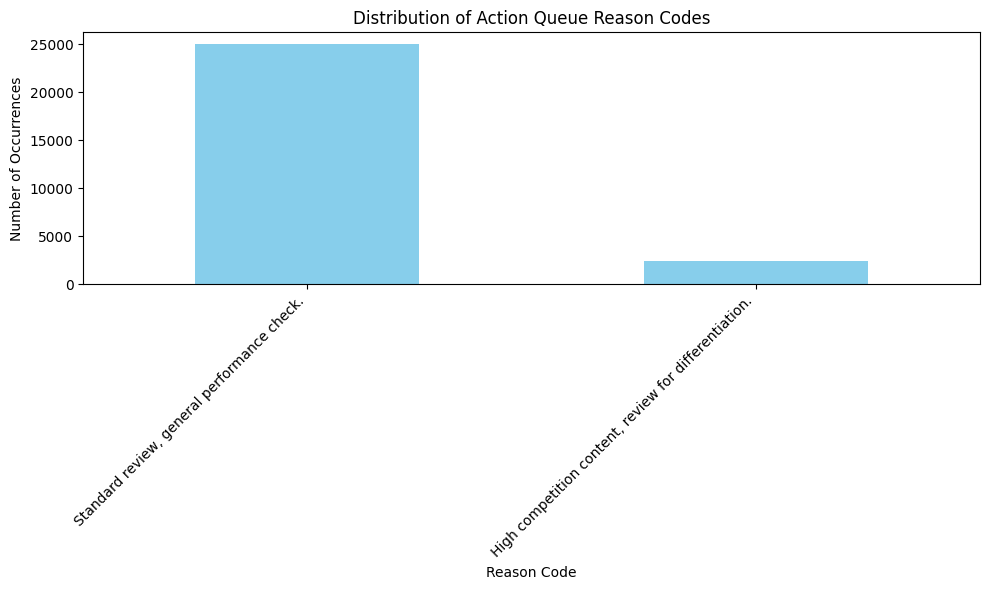

/tmp/ipykernel_1236/1325293683.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tier', y='ER%', data=fresh_df, ax=axes[0, 0], palette='Blues_d')
/tmp/ipykernel_1236/1325293683.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Level', y='Clicks', data=comp_df, ax=axes[0, 1], palette='Greens_d')
/tmp/ipykernel_1236/1325293683.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Type', y='CTR%', data=type_df, ax=axes[1, 0], palette='Oranges_d')
/tmp/ipykernel_1236/1325293683.py:43: FutureWarning: 

Passing `palette` without assi

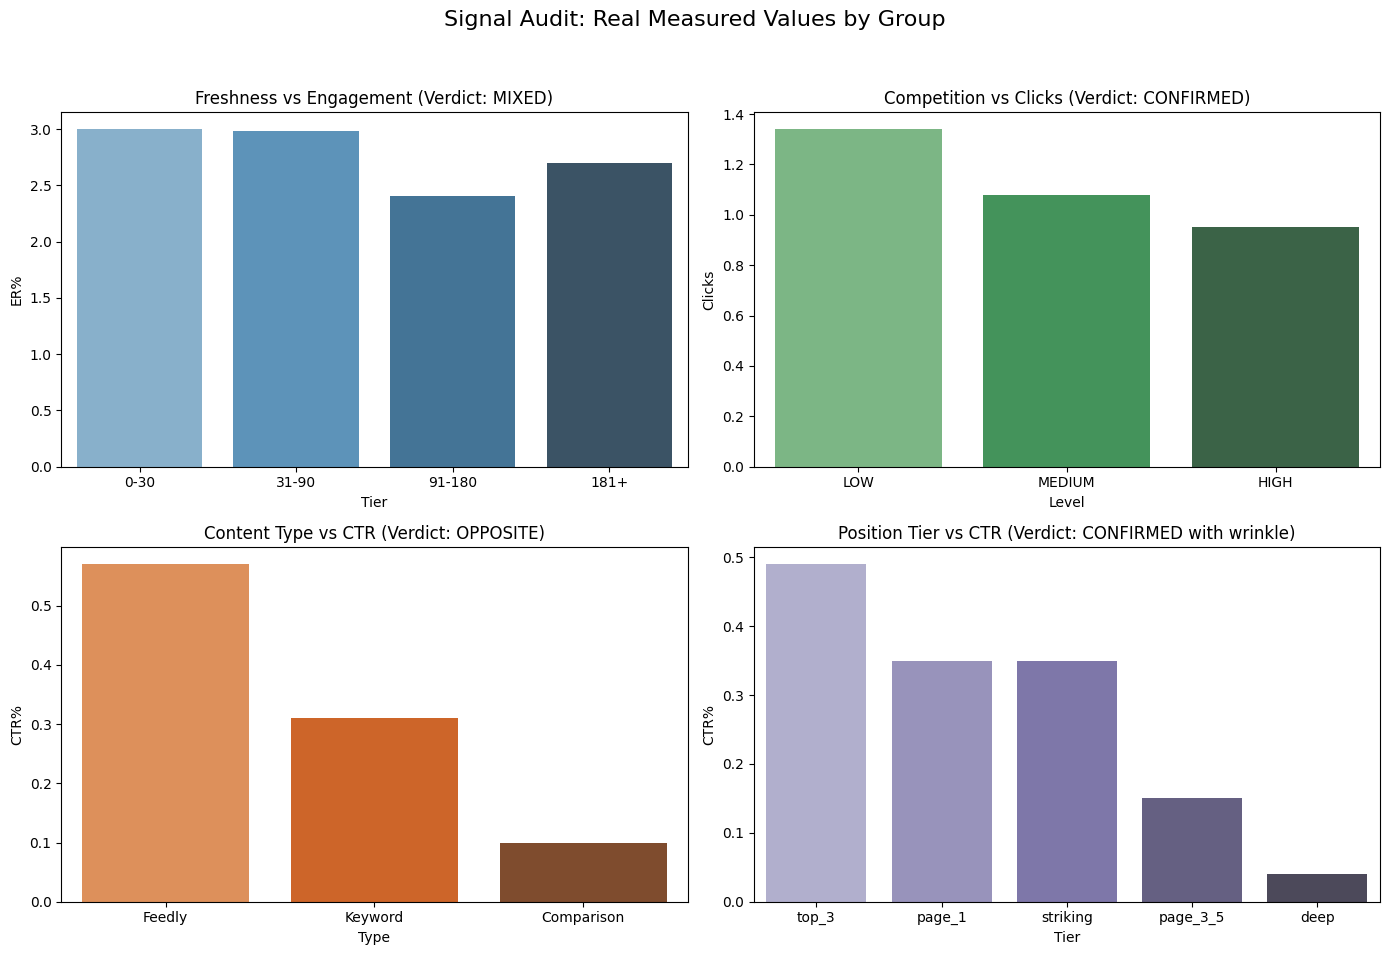

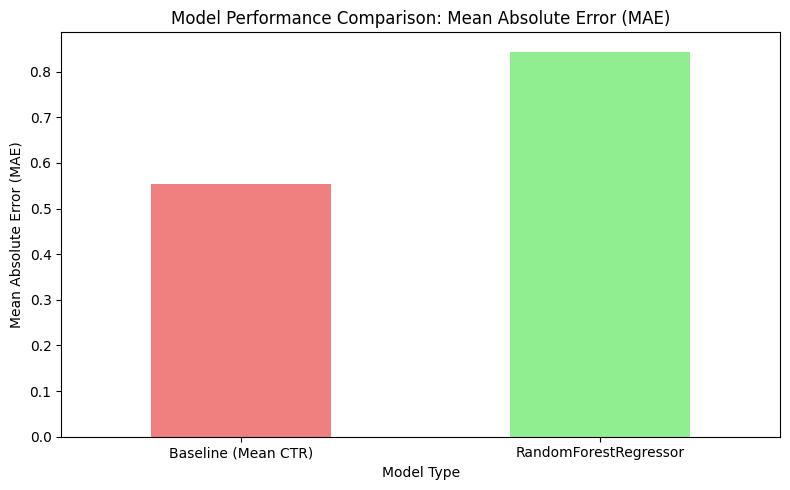

In [12]:
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd

# Ensure the output directory exists
output_dir = 'my-ml-starter/work/outputs/'
os.makedirs(output_dir, exist_ok=True)

# 1. Reason codes distribution bar chart from w07
reason_counts = ranks_recommendations_df['reason_codes'].str.split('; ').explode().value_counts()
fig1, ax1 = plt.subplots(figsize=(10, 6))
reason_counts.plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Distribution of Action Queue Reason Codes')
ax1.set_xlabel('Reason Code')
ax1.set_ylabel('Number of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'reason_codes_distribution.png'))
plt.show()

# 2. Signal Audit: Real Measured Values by Group (Replaces Simulated Chart)
fig2, axes = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle('Signal Audit: Real Measured Values by Group', fontsize=16)

# Freshness -> engagement (weighted engagement rate %)
fresh_df = pd.DataFrame({'Tier': ['0-30', '31-90', '91-180', '181+'], 'ER%': [3.00, 2.98, 2.41, 2.70]})
sns.barplot(x='Tier', y='ER%', data=fresh_df, ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Freshness vs Engagement (Verdict: MIXED)')

# Competition -> clicks (mean log1p(clicks_90d))
comp_df = pd.DataFrame({'Level': ['LOW', 'MEDIUM', 'HIGH'], 'Clicks': [1.34, 1.08, 0.95]})
sns.barplot(x='Level', y='Clicks', data=comp_df, ax=axes[0, 1], palette='Greens_d')
axes[0, 1].set_title('Competition vs Clicks (Verdict: CONFIRMED)')

# Content type -> CTR (weighted CTR %)
type_df = pd.DataFrame({'Type': ['Feedly', 'Keyword', 'Comparison'], 'CTR%': [0.57, 0.31, 0.10]})
sns.barplot(x='Type', y='CTR%', data=type_df, ax=axes[1, 0], palette='Oranges_d')
axes[1, 0].set_title('Content Type vs CTR (Verdict: OPPOSITE)')

# Position tier -> CTR (weighted CTR %)
pos_df = pd.DataFrame({'Tier': ['top_3', 'page_1', 'striking', 'page_3_5', 'deep'], 'CTR%': [0.49, 0.35, 0.35, 0.15, 0.04]})
sns.barplot(x='Tier', y='CTR%', data=pos_df, ax=axes[1, 1], palette='Purples_d')
axes[1, 1].set_title('Position Tier vs CTR (Verdict: CONFIRMED with wrinkle)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(output_dir, 'signal_audit_verdicts_effects.png'))
plt.show()

# 3. Bar chart comparing baseline vs model MAE from Section 4
mae_data = comparison_df[comparison_df['Metric'] == 'MAE'].set_index('Metric')
mae_values = mae_data.loc['MAE', ['Baseline (Mean CTR)', 'RandomForestRegressor']]

fig3, ax3 = plt.subplots(figsize=(8, 5))
mae_values.plot(kind='bar', ax=ax3, color=['lightcoral', 'lightgreen'])
ax3.set_title('Model Performance Comparison: Mean Absolute Error (MAE)')
ax3.set_xlabel('Model Type')
ax3.set_ylabel('Mean Absolute Error (MAE)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'model_mae_comparison.png'))
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.